Column names: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Data types:
 age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Shape: (4521, 17)
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  m

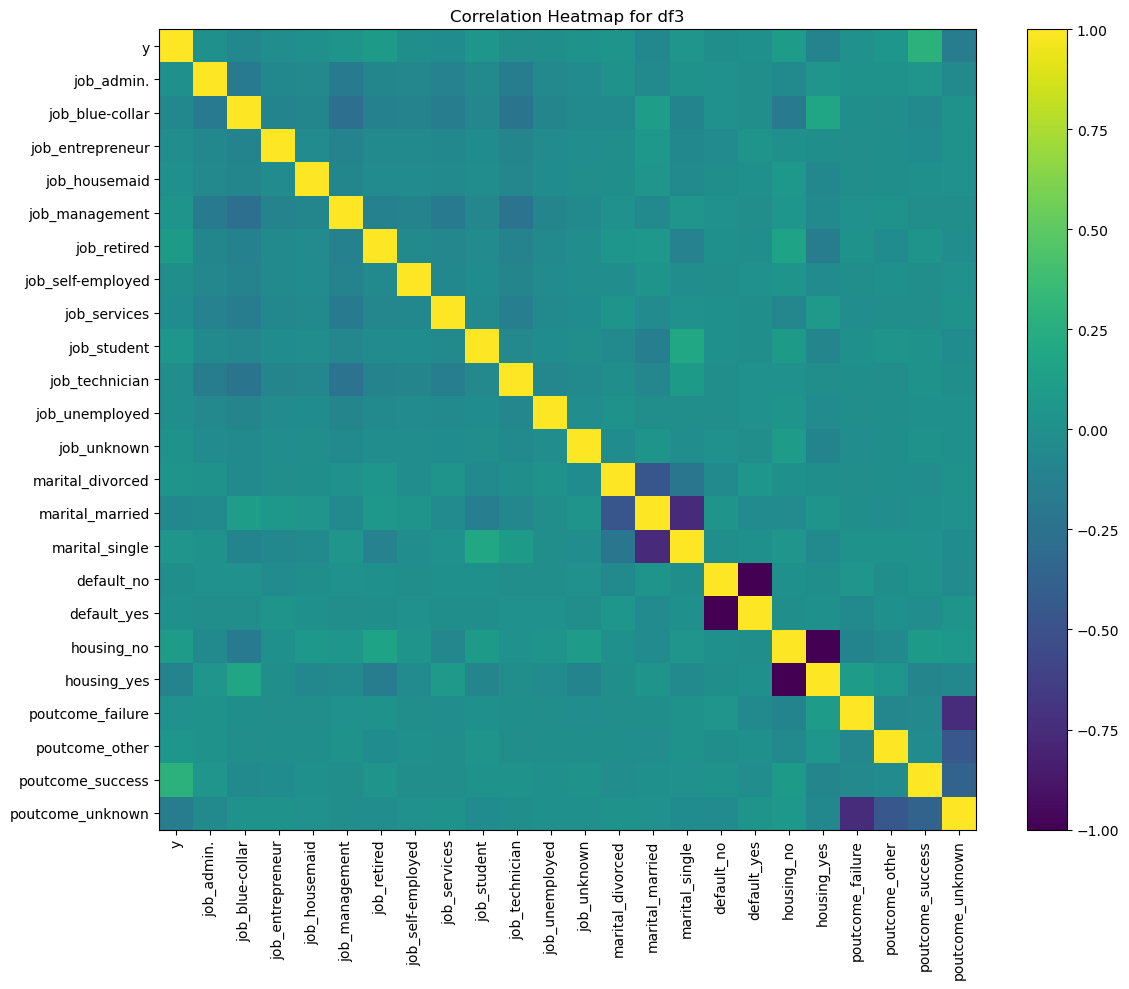


Training set shape: (3390, 23)
Testing set shape: (1131, 23)

Confusion Matrix:
[[987  14]
 [113  17]]

Accuracy Score: 0.887709991158267


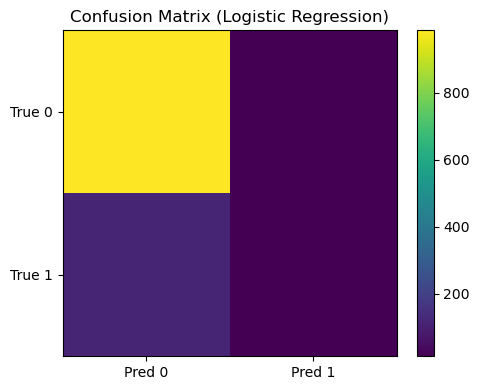

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

df = pd.read_csv("bank.csv", sep=";")

print("Column names:", df.columns)
print("\nData types:\n", df.dtypes)
print("\nShape:", df.shape)
print(df.head())

cols = ['y', 'job', 'marital', 'default', 'housing', 'poutcome']
df2 = df[cols].copy()

print("\ndf2 preview:")
print(df2.head())

df3 = pd.get_dummies(df2, columns=['job','marital','default','housing','poutcome'])

df3['y'] = df3['y'].map({'yes': 1, 'no': 0})

print("\ndf3 preview:")
print(df3.head())

corr = df3.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect='auto', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation Heatmap for df3")
plt.tight_layout()
plt.show()

y = df3['y']
X = df3.drop(columns=['y'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nTraining set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nAccuracy Score:", acc)

# Confusion matrix heatmap
plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', aspect='auto')
plt.colorbar()
plt.xticks([0,1], ['Pred 0','Pred 1'])
plt.yticks([0,1], ['True 0','True 1'])
plt.title('Confusion Matrix (Logistic Regression)')
plt.tight_layout()
plt.show()



In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

df = pd.read_csv("bank.csv", sep=";")

X = df[["age"]]          
y = df["balance"]        

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

normalizer = MinMaxScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

standardizer = StandardScaler()
X_train_std = standardizer.fit_transform(X_train)
X_test_std = standardizer.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² score:", r2)



R² score: -0.1755250439027667
